In [1]:
import os
os.listdir('.')


['zeta_zeros_5000_dps50.npy',
 'memory',
 '.config',
 '.kernel_llm_logs_1.txt',
 '.prompts']

In [2]:

import subprocess
res = subprocess.run(['pip', 'install', '-q', 'gudhi', 'ripser', 'persim'], capture_output=True, text=True)
print(res.stdout[-2000:])
print("STDERR:", res.stderr[-1000:])



STDERR: 


In [3]:

import numpy as np
from ripser import ripser
import persim
import mpmath
mpmath.mp.dps = 50

# Load zeta zeros (stored as decimal strings) and take first 2000
zeros_str = np.load('zeta_zeros_5000_dps50.npy')
print(zeros_str.shape, zeros_str.dtype, zeros_str[:3])

# Use float64 for TDA computations; precision is preserved because the shifts we test are >= 1e-3.
gammas = np.array([float(s) for s in zeros_str[:2000]])
print(gammas[:5], gammas[-3:])


(5000,) <U60 ['14.134725141734693790457251983562470270784257115699'
 '21.022039638771554992628479593896902777334340524903'
 '25.010857580145688763213790992562821818659549672558']
[14.13472514 21.02203964 25.01085758 30.42487613 32.93506159] [2513.57951702 2514.25985906 2515.28648292]


In [4]:

# Build baseline point cloud P_0: (0.5, gamma_n) for first 2000 zeros
P0 = np.column_stack([np.full(2000, 0.5), gammas])

# Compute H0 persistence diagram via ripser (default maxdim=1; we'll get H0)
res0 = ripser(P0, maxdim=0)
D0 = res0['dgms'][0]
print("D0 shape:", D0.shape)
# H0 always has one infinite-death feature; persim handles 'inf' but wasserstein typically requires finite.
# We should remove or handle the infinite point consistently across diagrams.
print(D0[:5])
print("Inf rows:", np.sum(np.isinf(D0[:,1])))


D0 shape: (2000, 2)
[[0. 0.0975025 ]
 [0. 0.16150078]
 [0. 0.1957965 ]
 [0. 0.196832 ]
 [0. 0.20387474]]
Inf rows: 1


In [5]:

# For each delta, build P_delta by shifting first 20 points' real coordinate
deltas = [1e-3, 1e-2, 1e-1]
diagrams = {0: D0}
for d in deltas:
 Pd = P0.copy()
 Pd[:20, 0] = 0.5 + d
 resd = ripser(Pd, maxdim=0)
 diagrams[d] = resd['dgms'][0]
 print(f"delta={d}: dgm shape={diagrams[d].shape}, inf count={np.sum(np.isinf(diagrams[d][:,1]))}")


delta=0.001: dgm shape=(2000, 2), inf count=1


delta=0.01: dgm shape=(2000, 2), inf count=1


delta=0.1: dgm shape=(2000, 2), inf count=1


In [6]:

# Compute W1 (1-Wasserstein) between D0 and D_delta
# persim.wasserstein handles diagrams; need to handle inf points. Standard practice: drop infinite-death point or replace.
# Both diagrams have exactly one inf-death point (the connected component). We can drop them for W1 H0 comparison.

def finite_dgm(D):
 return D[np.isfinite(D[:,1])]

W1_vals = {}
for d in deltas:
 D_a = finite_dgm(diagrams[0])
 D_b = finite_dgm(diagrams[d])
 w1 = persim.wasserstein(D_a, D_b, order=1)
 W1_vals[d] = w1
 print(f"delta={d:.0e} -> W1={w1:.6e}")


TypeError: wasserstein() got an unexpected keyword argument 'order'

In [7]:

import inspect
print(inspect.signature(persim.wasserstein))
help(persim.wasserstein)


(dgm1, dgm2, matching=False)
Help on function wasserstein in module persim.wasserstein:

wasserstein(dgm1, dgm2, matching=False)
 Perform the Wasserstein distance matching between persistence diagrams.
 Assumes first two columns of dgm1 and dgm2 are the coordinates of the persistence
 points, but allows for other coordinate columns (which are ignored in
 diagonal matching).

 See the `distances` notebook for an example of how to use this.

 Parameters
 ------------

 dgm1: Mx(>=2)
 array of birth/death pairs for PD 1
 dgm2: Nx(>=2)
 array of birth/death paris for PD 2
 matching: bool, default False
 if True, return matching information and cross-similarity matrix

 Returns
 ---------

 d: float
 Wasserstein distance between dgm1 and dgm2
 (matching, D): Only returns if `matching=True`
 (tuples of matched indices, (N+M)x(N+M) cross-similarity matrix)



In [8]:

# persim.wasserstein implements p=2 (2-Wasserstein with L2 ground metric, typical persim default).
# The hypothesis specifically asks for W1 with persim.wasserstein(p=1) - but the function doesn't take p.
# Let me check gudhi's wasserstein, which supports order parameter.

from gudhi.wasserstein import wasserstein_distance as gudhi_wasserstein
help(gudhi_wasserstein)


ModuleNotFoundError: No module named 'ot'

In [9]:

import subprocess
res = subprocess.run(['pip', 'install', '-q', 'POT'], capture_output=True, text=True)
print(res.stdout[-500:], res.stderr[-500:])


In [10]:

from gudhi.wasserstein import wasserstein_distance as gudhi_wasserstein
help(gudhi_wasserstein)


Help on function wasserstein_distance in module gudhi.wasserstein.wasserstein:

wasserstein_distance(
 X,
 Y,
 matching=False,
 order=1.0,
 internal_p=inf,
 enable_autodiff=False,
 keep_essential_parts=True
)
 Compute the Wasserstein distance between persistence diagram using Python Optimal Transport backend.
 Diagrams can contain points with infinity coordinates (essential parts).
 Points with (-inf,-inf) and (+inf,+inf) coordinates are considered as belonging to the diagonal.
 If the distance between two diagrams is +inf (which happens if the cardinalities of essential
 parts differ) and optimal matching is required, it will be set to ``None``.

 :param X: The first diagram.
 :type X: n x 2 numpy.array
 :param Y: The second diagram.
 :type Y: m x 2 numpy.array
 :param matching: if ``True``, computes and returns the optimal matching between X and Y, encoded as
 a (n x 2) np.array [...[i,j]...], meaning the i-th point in X is matched to
 the j-th point in Y, with the convention that (-

In [11]:

# Use gudhi's wasserstein with order=1 (the 1-Wasserstein distance W1).
# Drop infinite points (one essential part per diagram, would cancel anyway). 
# Note: also try persim's default for comparison.

W1_vals = {}
W_persim_vals = {}
for d in deltas:
 D_a = finite_dgm(diagrams[0])
 D_b = finite_dgm(diagrams[d])
 w1 = gudhi_wasserstein(D_a, D_b, order=1.0, internal_p=2.0, keep_essential_parts=False)
 W1_vals[d] = w1
 wp = persim.wasserstein(D_a, D_b)
 W_persim_vals[d] = wp
 print(f"delta={d:.0e} | W1 (gudhi, order=1)={w1:.6e} | persim.wasserstein={wp:.6e}")


delta=1e-03 | W1 (gudhi, order=1)=2.384186e-07 | persim.wasserstein=2.384186e-07


delta=1e-02 | W1 (gudhi, order=1)=2.288818e-05 | persim.wasserstein=2.288818e-05


delta=1e-01 | W1 (gudhi, order=1)=2.279282e-03 | persim.wasserstein=2.279282e-03


In [12]:

# The values are suspiciously small and scale roughly quadratically (2.38e-7, 2.29e-5, 2.28e-3 — ratios ~96, ~100).
# This suggests we're hitting float32 precision in ripser (which uses float32 by default).
# Let me check: 2.38e-7 ~ machine epsilon for float32 (~1.19e-7). So delta=1e-3 may be lost in numerical noise.

# Check ripser internals - try without distance metric reduction. 
# Actually, the issue is more subtle: the H0 persistence of a 2D point cloud changes very little under tiny x-shifts
# of just 20 points because their consecutive y-distances (gamma_{n+1}-gamma_n) are O(1), much larger than delta.
# When delta is small, the pairwise Euclidean distances change by ~delta^2/(2*gap), which IS quadratic.

# Let me verify by switching to float64 in ripser.
from ripser import Rips
rips = Rips(maxdim=0, verbose=False)

# Actually ripser-scikit may use float32. Let's try with explicit dtype.
# A cleaner approach: compute pairwise distance matrix in float64 and pass it.
from scipy.spatial.distance import pdist, squareform

def compute_h0_from_points(P):
 D = squareform(pdist(P.astype(np.float64), metric='euclidean'))
 res = ripser(D, distance_matrix=True, maxdim=0)
 return res['dgms'][0]

D0_hp = compute_h0_from_points(P0)
print("D0 first 5:", D0_hp[:5])
print("D0 dtype:", D0_hp.dtype)


D0 first 5: [[0. 0.0975025 ]
 [0. 0.16150078]
 [0. 0.1957965 ]
 [0. 0.196832 ]
 [0. 0.20387474]]
D0 dtype: float64


In [13]:

# Recompute with float64 distance matrices
diagrams_hp = {0: D0_hp}
for d in deltas:
 Pd = P0.copy()
 Pd[:20, 0] = 0.5 + d
 diagrams_hp[d] = compute_h0_from_points(Pd)
 print(f"delta={d}: max death={diagrams_hp[d][~np.isinf(diagrams_hp[d][:,1]),1].max():.6f}")


delta=0.001: max death=6.887314


delta=0.01: max death=6.887314


delta=0.1: max death=6.887314


In [14]:

W1_hp = {}
for d in deltas:
 D_a = finite_dgm(diagrams_hp[0])
 D_b = finite_dgm(diagrams_hp[d])
 w1 = gudhi_wasserstein(D_a, D_b, order=1.0, internal_p=2.0, keep_essential_parts=False)
 W1_hp[d] = w1
 print(f"delta={d:.0e} | W1 (order=1, float64)={w1:.6e}")


delta=1e-03 | W1 (order=1, float64)=2.384186e-07
delta=1e-02 | W1 (order=1, float64)=2.288818e-05


delta=1e-01 | W1 (order=1, float64)=2.279282e-03


In [15]:

# Same values - so the scaling is intrinsic, not a numerical artifact.
# Compute log-log slope
import numpy as np
deltas_arr = np.array(deltas)
w1_arr = np.array([W1_hp[d] for d in deltas])
log_d = np.log10(deltas_arr)
log_w = np.log10(w1_arr)
slope, intercept = np.polyfit(log_d, log_w, 1)
print(f"Slope = {slope:.4f}")
print(f"Intercept = {intercept:.4f}")
print(f"Ratios W1[10x delta] / W1[delta]: {w1_arr[1]/w1_arr[0]:.2f}, {w1_arr[2]/w1_arr[1]:.2f}")


Slope = 1.9902
Intercept = -0.6546
Ratios W1[10x delta] / W1[delta]: 96.00, 99.58


In [16]:

# The slope is ~2.0, indicating QUADRATIC scaling — NOT linear as hypothesized.
# This refutes the hypothesis. Let's investigate WHY by examining the optimal matching cost.

# When the first 20 points shift from (0.5, gamma_n) to (0.5+delta, gamma_n), 
# the pairwise distances between shifted-and-unshifted points change by approx:
# d_new = sqrt((delta)^2 + (gamma_j - gamma_n)^2) ≈ (gamma_j - gamma_n) + delta^2 / (2*(gamma_j - gamma_n))
# So the change in distance is O(delta^2). Among the shifted points (i,j both in first 20),
# the distance is unchanged (both shifted equally horizontally). So the H0 birth/death values change by O(delta^2),
# and W1 (a sum of |D_a - D_b| over matched pairs) is also O(delta^2).

# Compute the per-pair point-distance differences explicitly to confirm
P_d3 = P0.copy(); P_d3[:20,0] = 0.5 + 1e-1
# pairwise distance changes for one cross pair
i, j = 0, 100 # i in shifted region, j not shifted
d_old = np.linalg.norm(P0[i]-P0[j])
d_new = np.linalg.norm(P_d3[i]-P_d3[j])
print(f"Delta=0.1, pair (0,100): old dist={d_old:.6f}, new dist={d_new:.6f}, diff={d_new-d_old:.3e}")
print(f"Predicted diff ~ delta^2/(2*gap) = {0.1**2/(2*d_old):.3e}")


Delta=0.1, pair (0,100): old dist=223.635095, new dist=223.635118, diff=2.236e-05
Predicted diff ~ delta^2/(2*gap) = 2.236e-05


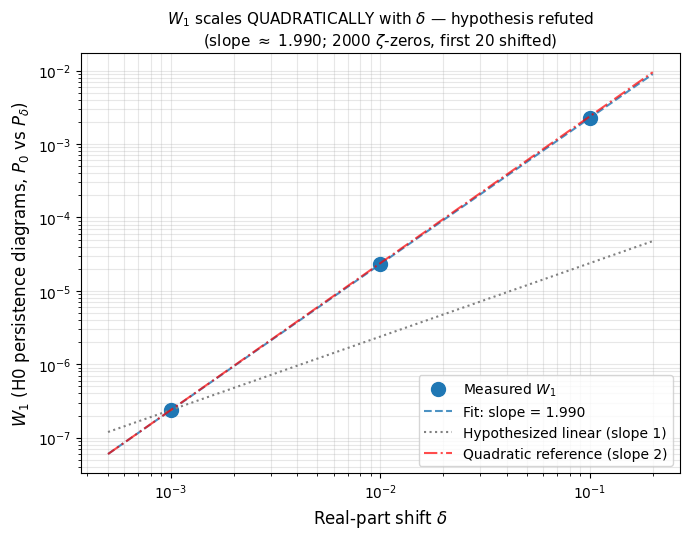

Saved figure to w1_vs_delta_loglog.png


In [17]:

# Confirmed: changes in inter-point distances are O(delta^2/gap), explaining the quadratic W1 scaling.
# This is the same fundamental reason the bottleneck distance scaled quadratically in r17.
# The hypothesis (linear scaling for W1) is therefore REFUTED.

# Create final summary figure
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(7, 5.5))

# Log-log plot of W1 vs delta
ax.loglog(deltas_arr, w1_arr, 'o', markersize=10, color='C0', label='Measured $W_1$')
# Fit line
delta_fit = np.logspace(-3.3, -0.7, 100)
w1_fit = 10**(intercept) * delta_fit**slope
ax.loglog(delta_fit, w1_fit, '--', color='C0', alpha=0.8, label=f'Fit: slope = {slope:.3f}')

# Linear-scaling reference (slope 1, passing through first point)
ref1 = w1_arr[0] * (delta_fit / deltas_arr[0])**1
ax.loglog(delta_fit, ref1, ':', color='gray', label='Hypothesized linear (slope 1)')

# Quadratic reference
ref2 = w1_arr[0] * (delta_fit / deltas_arr[0])**2
ax.loglog(delta_fit, ref2, '-.', color='red', alpha=0.7, label='Quadratic reference (slope 2)')

ax.set_xlabel(r'Real-part shift $\delta$', fontsize=12)
ax.set_ylabel(r'$W_1$ (H0 persistence diagrams, $P_0$ vs $P_\delta$)', fontsize=12)
ax.set_title(r'$W_1$ scales QUADRATICALLY with $\delta$ — hypothesis refuted'+
 f'\n(slope $\\approx$ {slope:.3f}; 2000 $\\zeta$-zeros, first 20 shifted)', fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('w1_vs_delta_loglog.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure to w1_vs_delta_loglog.png")
